# Project_1: To predict happiness

#### We need to predict the happiness score considering all the other factors mentioned in the dataset.

In [122]:
#Import Necessary Libraries
import numpy as np
import pandas as pd

#For DataVisualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

### 1. Load Dataset

In [126]:
data=pd.read_csv(r"C:\Users\HP\Downloads\Final Projects Machine Learning\Final Projects Machine Learning\Project 5.0\happiness_score_dataset.csv")
data.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [128]:
# Checking shape of our data (number of rows and columns)
data.shape

(158, 12)

In [130]:
# Checking the null values
data.isna().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

In [132]:
# There is no null values in our dataset

In [134]:
#Check any duplicate rows.
duplicate_rows = data[data.duplicated()]
print(duplicate_rows)

Empty DataFrame
Columns: [Country, Region, Happiness Rank, Happiness Score, Standard Error, Economy (GDP per Capita), Family, Health (Life Expectancy), Freedom, Trust (Government Corruption), Generosity, Dystopia Residual]
Index: []


In [136]:
# There is no duplicate rows we can go forward

In [138]:
# We are predicting Happiness score, so we can drop 'Happiness Rank'
data=data.drop(columns=['Happiness Rank'])

In [140]:
# Describe our dataset
data.describe()

,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


In [146]:
data=data.drop(columns=['Country','Region'],axis=1)

In [148]:
data.head()

,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


### 2. EDA (Exploratory Data Analysis)

#### We can use distribution plots to understand data

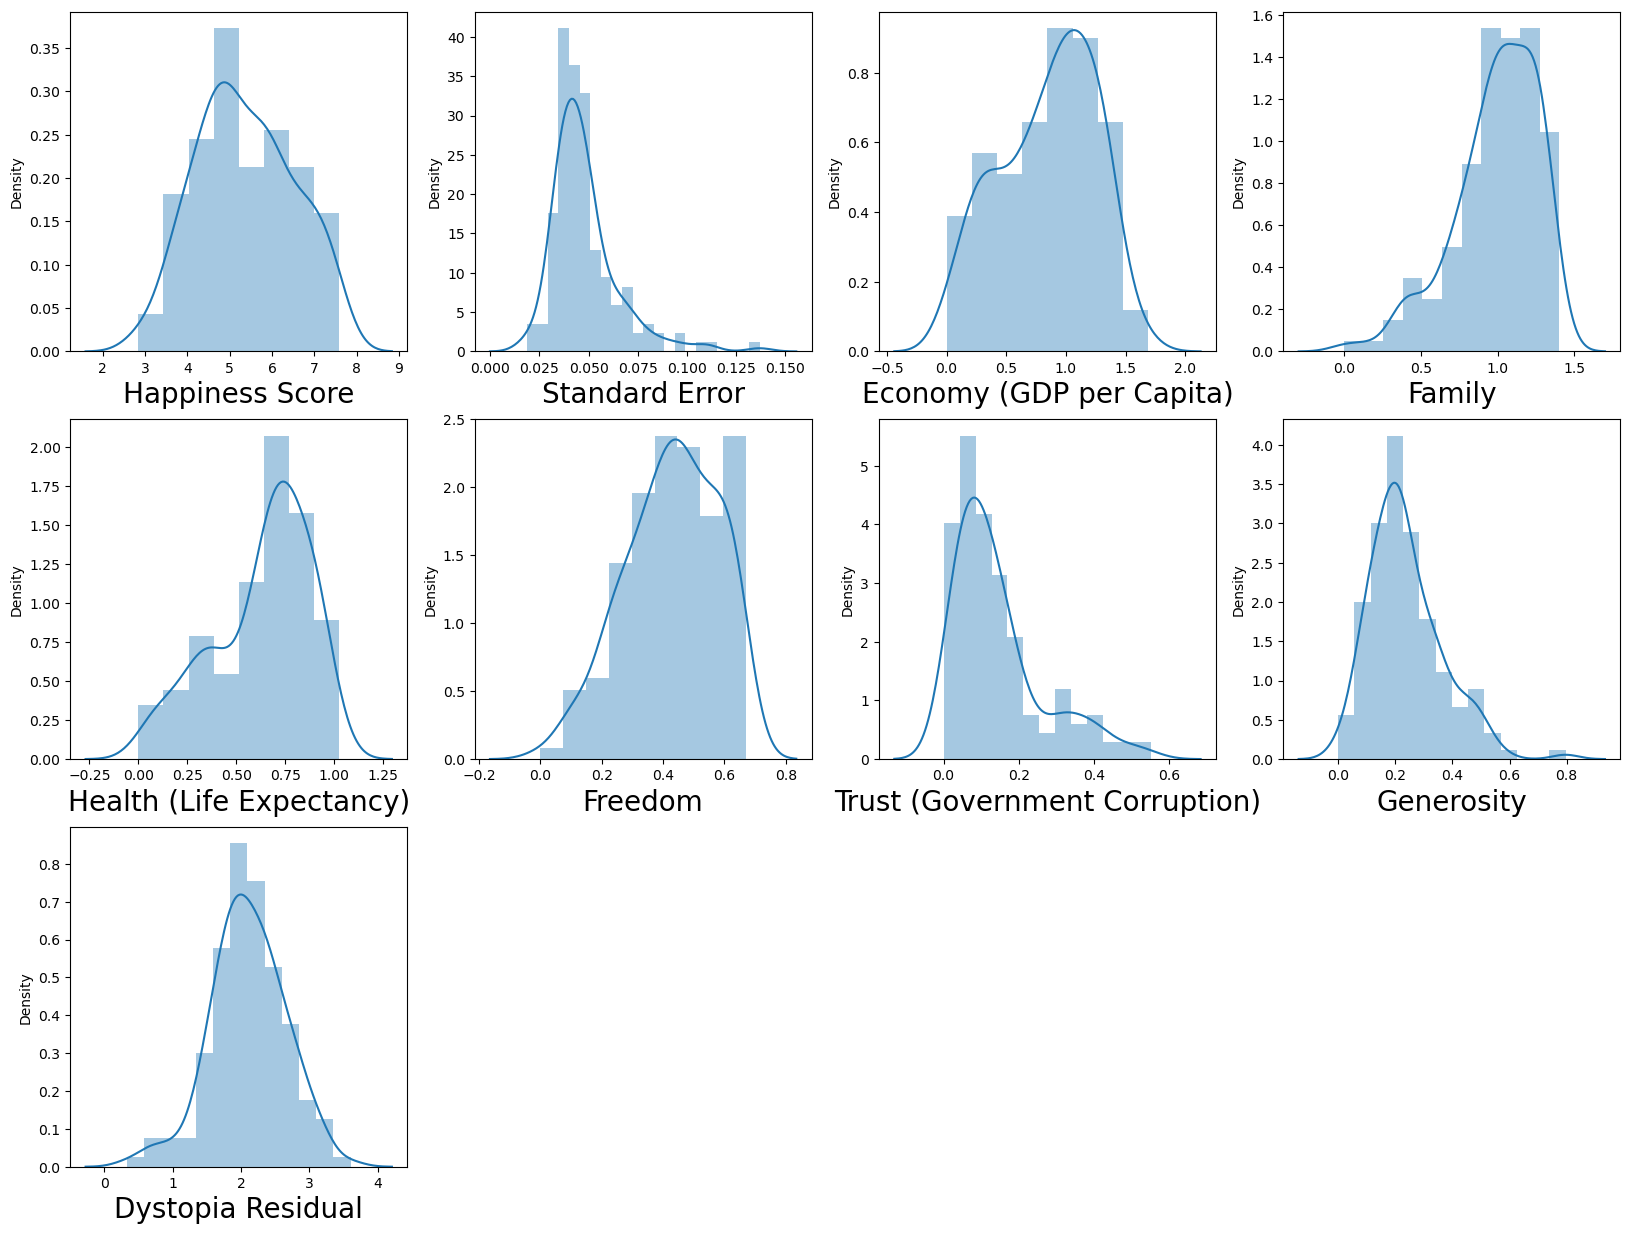

In [151]:
#Lets check how data is distributed
plt.figure(figsize=(20,15))
plotnumber =1
for column in df:
    if plotnumber <=10:
        ax=plt.subplot(3,4,plotnumber)
        sns.distplot(df[column])
        plt.xlabel(column,fontsize=20)
    plotnumber +=1
plt.show()

In [152]:
# Some outliers are present in our data

In [155]:
# From this distribution plot we can find some outliers in our data
#Firstly some missing values are present in 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy), 'Freedom' and 'Dystopia Residual', this features can't be zero, we need to solve it

### 3. Data Preprocessing

In [158]:
# Handling Missing values
#replacing zero values with the mean of the column
#i am going to use low risk method its mean method
#treating zeros

In [160]:
data['Family']=data['Family'].replace(0,data['Family'].mean())
data['Dystopia Residual']=df['Dystopia Residual'].replace(0,data['Dystopia Residual'].mean())
data['Economy (GDP per Capita)']=data['Economy (GDP per Capita)'].replace(0,data['Economy (GDP per Capita)'].mean())
data['Health (Life Expectancy)']=data['Health (Life Expectancy)'].replace(0,data['Health (Life Expectancy)'].mean())
data['Freedom']=data['Freedom'].replace(0,data['Freedom'].mean())
data.describe()

,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,5.375734,0.047885,0.851493,0.997318,0.634248,0.431328,0.143422,0.237296,2.098977
std,1.145010,0.017146,0.397388,0.260556,0.241870,0.146734,0.120034,0.126685,0.553550
min,2.839000,0.018480,0.015300,0.139950,0.047760,0.076990,0.000000,0.000000,0.328580
25%,4.526000,0.037268,0.557532,0.861422,0.447215,0.329603,0.061675,0.150553,1.759410
50%,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


In [164]:
#Change the columns name based on "encoded_data"
data.rename(columns={'Happiness Score':'happiness_score','Standard Error':'std_error','Economy (GDP per Capita)':'economy','Family':'family','Health (Life Expectancy)':'health',
                                                           'Freedom':'freedom','Trust (Government Corruption)':'trust_gov_corr','Generosity':'generosity', 'Dystopia Residual':'dystopia_res'}, inplace=True)
data.head()

,happiness_score,std_error,economy,family,health,freedom,trust_gov_corr,generosity,dystopia_res
0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


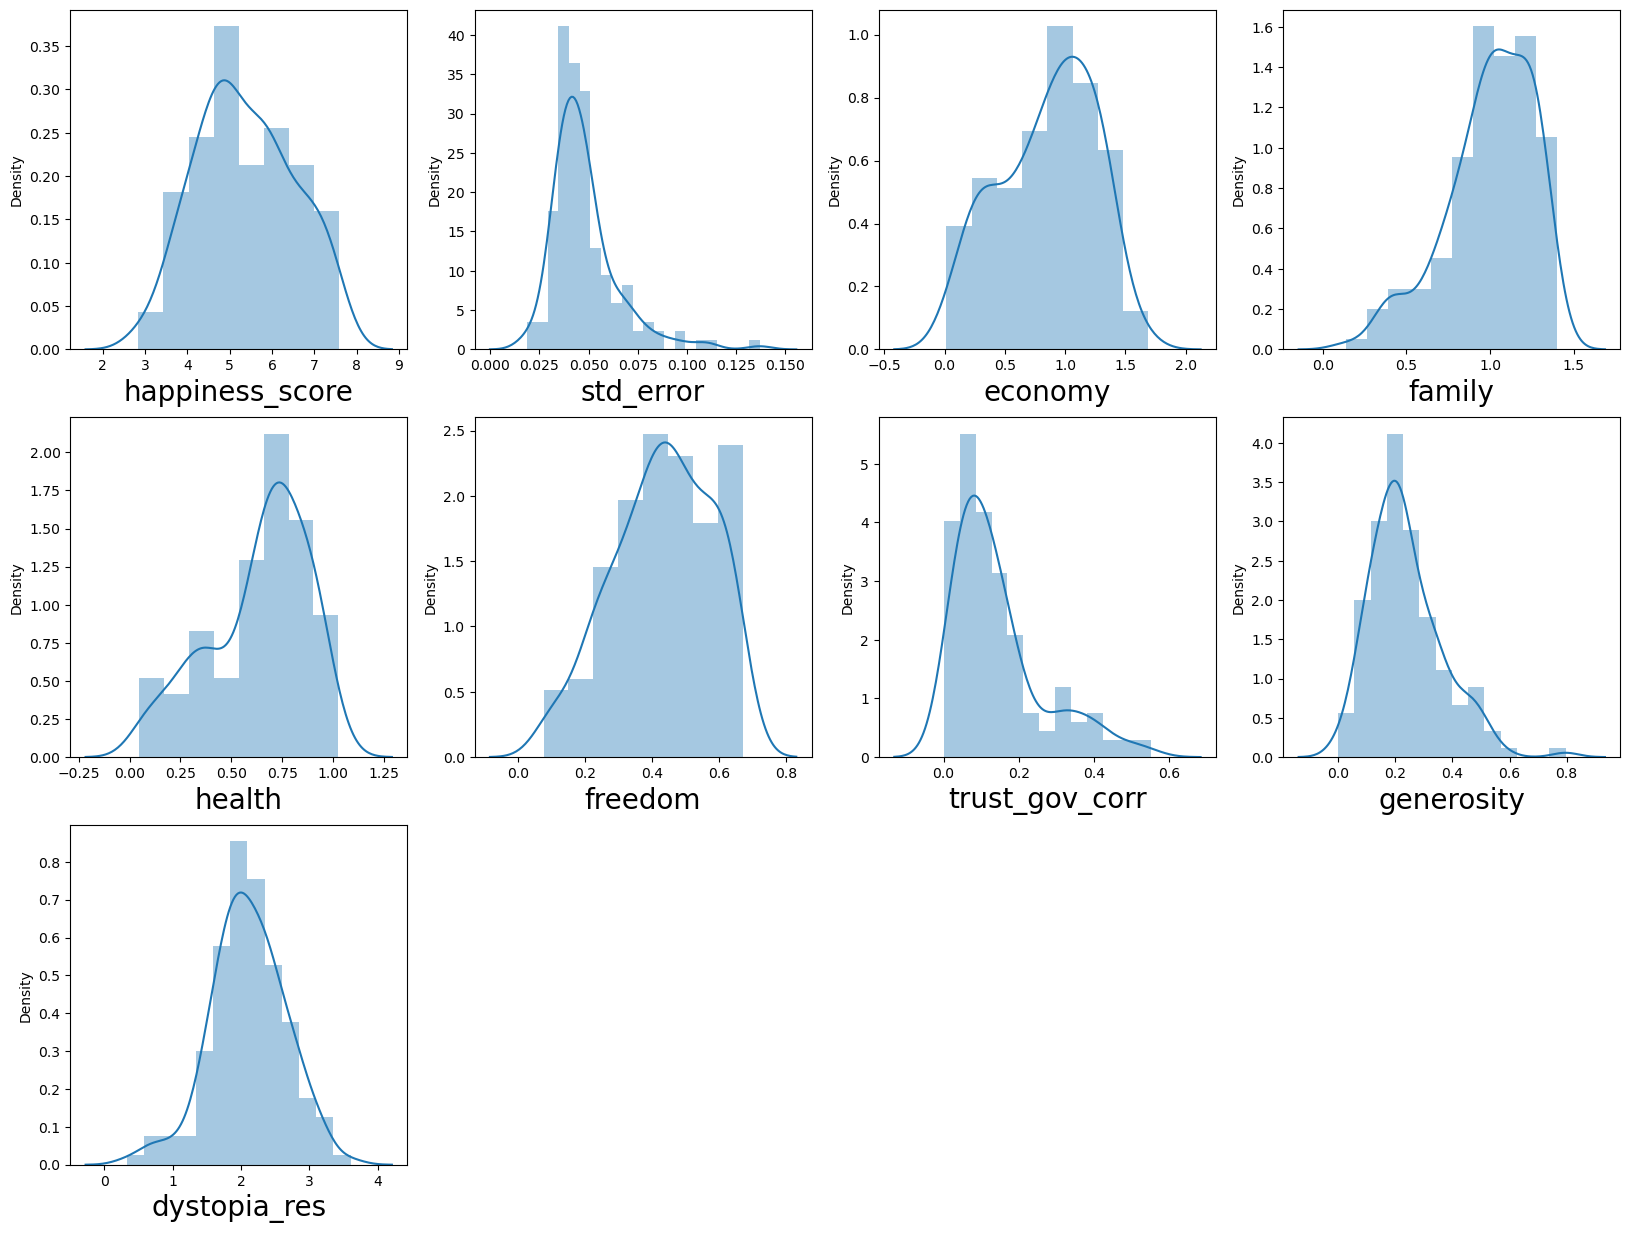

In [167]:
#Lets check how data is distributed
plt.figure(figsize=(20,15))
plotnumber =1
for column in data:
    if plotnumber <=12:
        ax=plt.subplot(3,4,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize=20)
    plotnumber +=1
plt.show()

In [169]:
# Handing Outliers: In order to handing outliers we need to plot 'box plot'

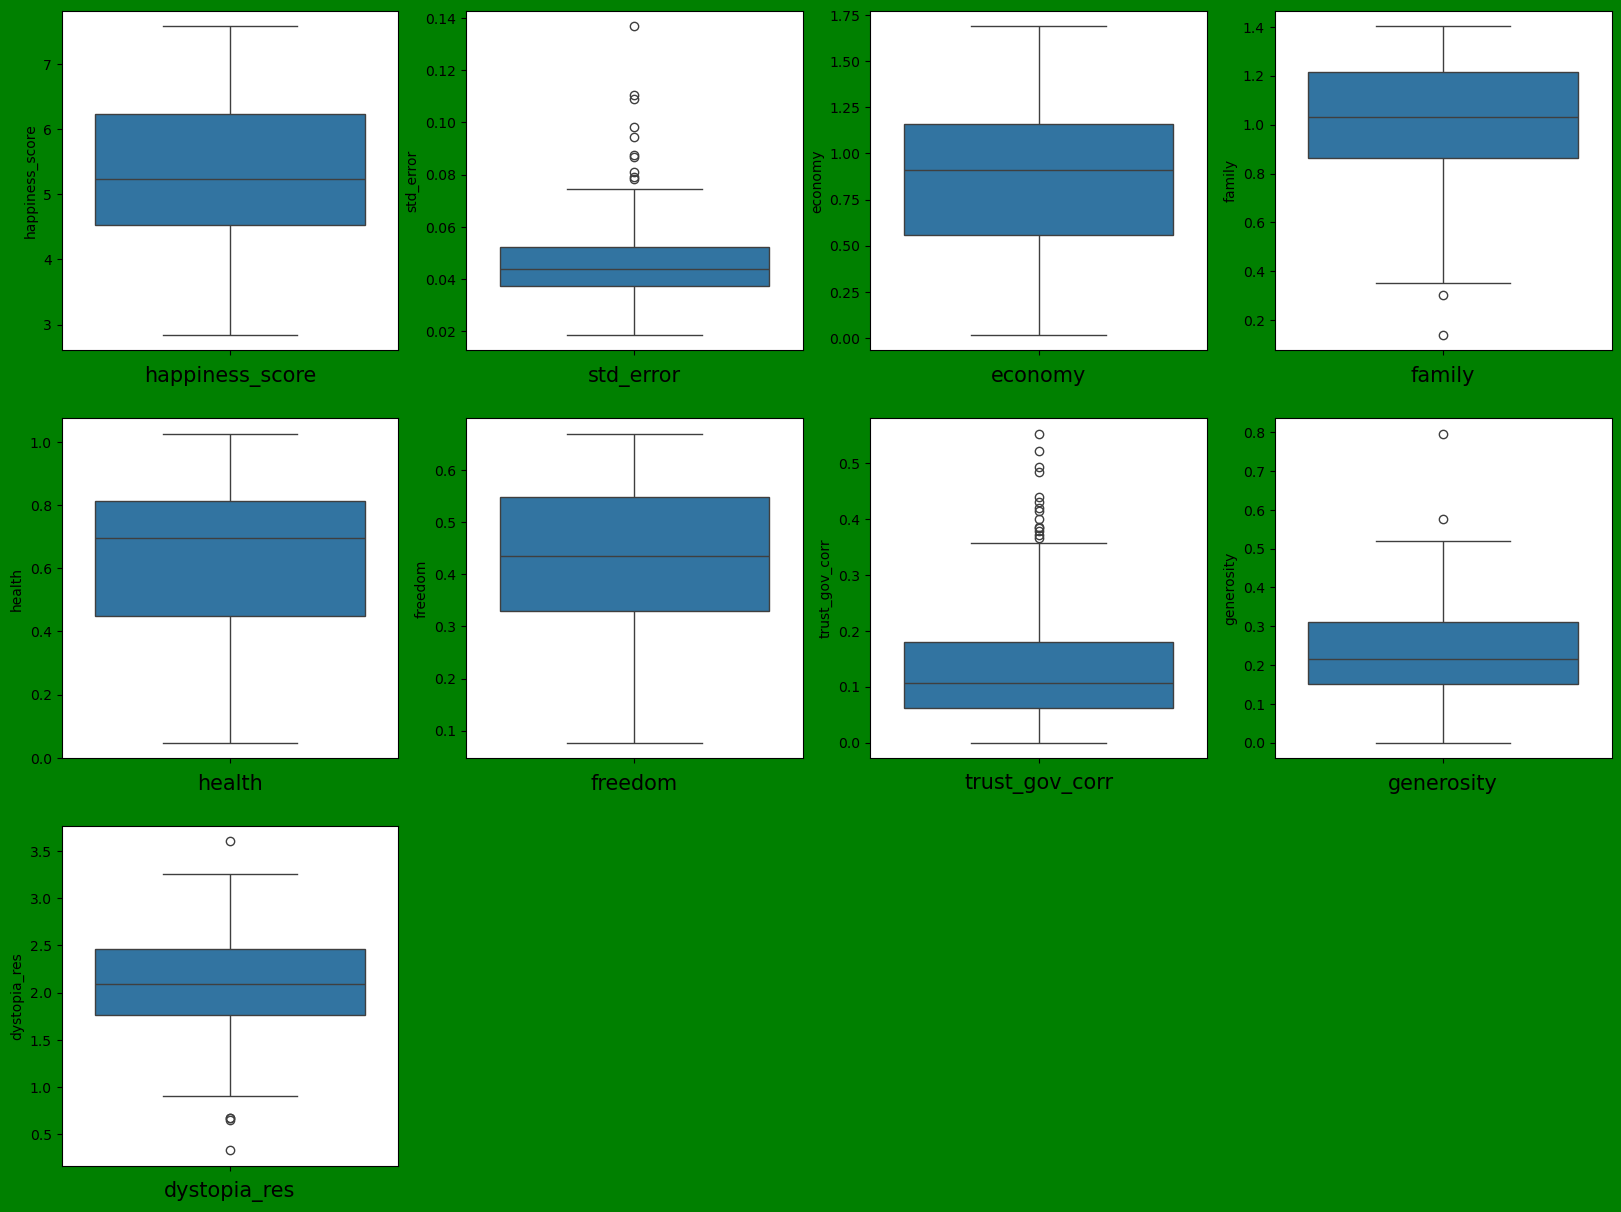

In [171]:
#Visualize the outliers using boxplot
plt.figure(figsize=(20,15),facecolor='green')
plotnumber=1
for column in data:
    if plotnumber <=12:
        plt.subplot(3,4,plotnumber)
        ax=sns.boxplot(data=data[column])
        plt.xlabel(column,fontsize=15)
    plotnumber +=1
plt.show()

In [173]:
#From boxplot we find that we have outliers in 'Standard Error', 'Family', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual   '
#Lets fix this with the using of z score

In [175]:
from scipy.stats import zscore

In [177]:
z_score=zscore(data[['std_error', 'family', 'trust_gov_corr', 'generosity', 'dystopia_res']])
score=np.abs(z_score)
filter=(score <3).all(axis=1)
data=data[filter]
data.shape	

(150, 9)

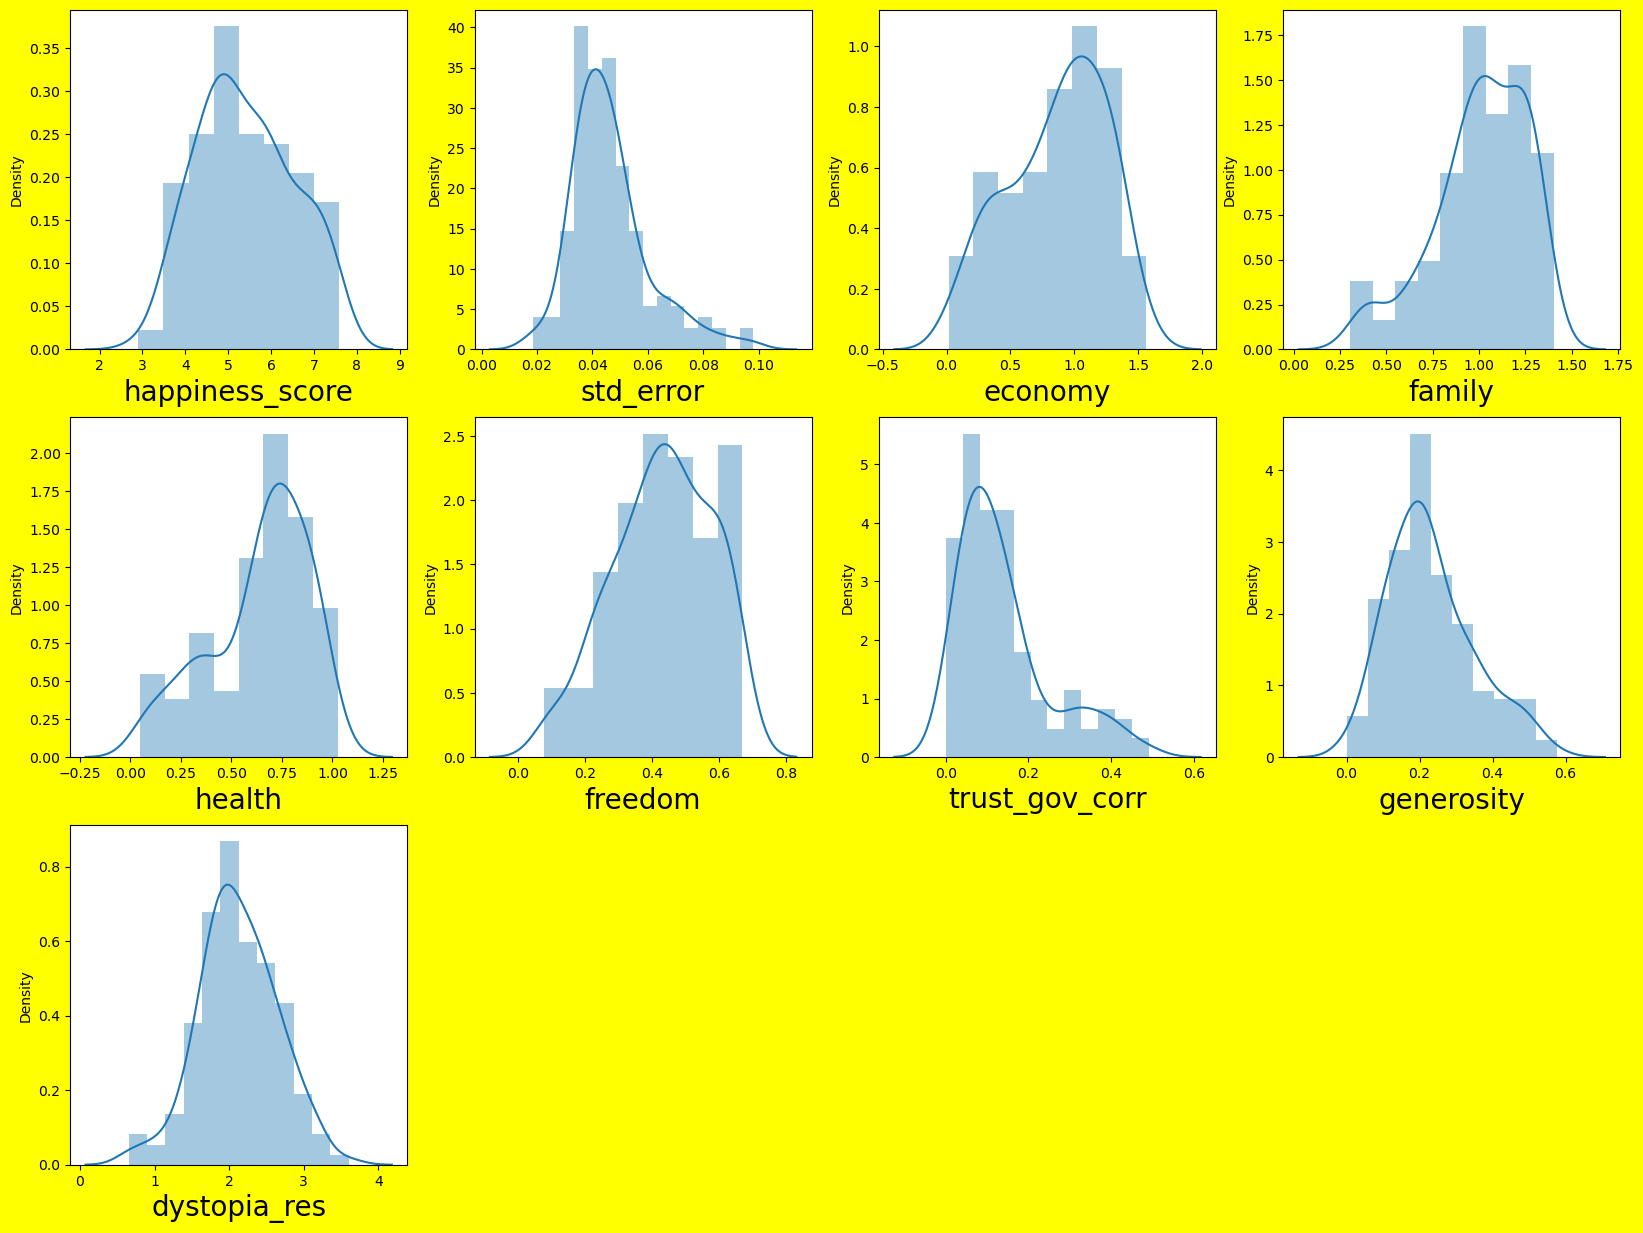

In [179]:
#So, we can plot distribution once again
plt.figure(figsize=(20,15), facecolor='yellow')
plotnumber =1
for column in data:
    if plotnumber <=12:
        ax=plt.subplot(3,4,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize=20)
    plotnumber +=1
plt.show()

In [181]:
#Now our data is normaly distributed, we can proceed with feature selection.

#### Feature Selection

In [184]:
#Lets check in VIF .Variance Inflation Factor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

In [186]:
x=data.drop(columns=['happiness_score'])
y=data['happiness_score']

In [188]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled

array([[-0.87351634,  1.38949251,  1.36287367, ...,  2.48179921,
         0.54774599,  0.7484519 ],
       [ 0.17850856,  1.14437383,  1.57357697, ...,  0.01267166,
         1.7192371 ,  1.10051263],
       [-0.93279541,  1.20464508,  1.40711657, ...,  3.04769454,
         0.92231751,  0.70013246],
       ...,
       [-1.10706158, -1.41246974, -2.82025816, ..., -0.37996868,
         1.12140047, -0.32944923],
       [-0.69853596, -1.49879086, -2.61638914, ..., -0.53157789,
        -0.41097574, -0.93738944],
       [ 2.8739206 , -2.20494811, -2.36855698, ..., -0.34954039,
        -0.28779788, -0.55651629]])

In [190]:
vif=pd.DataFrame()
vif['vif']=[variance_inflation_factor(x_scaled,i)for i in range(x_scaled.shape[1])]
vif['features']=x.columns
vif

,vif,features
0,1.154938,std_error
1,3.817370,economy
2,1.943980,family
3,3.036343,health
4,1.895603,freedom
5,1.486651,trust_gov_corr
6,1.329234,generosity
7,1.030873,dystopia_res


In [192]:
#We dont have any multicollinearity problem. So we can go for model building

### 4. Model Building
#### Using Regression

In [195]:
# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [197]:
# Split into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [199]:
# Standardize data for models sensitive to scale (e.g., SVR, KNN)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [201]:
# Define models to evaluate
models = {
    "Linear Regression": LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

In [203]:
# Train and evaluate each model
print("Model Performance of Test data:\n")
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_train_pred = model.predict(x_train_scaled)
    
    #Calculate methrics 
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_train_pred)
    n = len(y_train)
    p = x.shape[1]
    adj_r2_train = (1-(1-r2_train)*(n-1)/(n-p-1))

    
    #Print all metrics
    print(f"{name}")
    print(f"  MAE: {mae_train:.3f}")
    print(f"  MSE: {mse_train:.3f}")
    print(f"  RMSE: {rmse_train:.3f}")
    print(f"  R_square Score: {r2_train:.3f}")
    print(f"  Adjusted R_square Score: {adj_r2_train:.3f}\n")

Model Performance of Test data:

Linear Regression
  MAE: 0.046
  MSE: 0.012
  RMSE: 0.108
  R_square Score: 0.991
  Adjusted R_square Score: 0.990

Decision Tree
  MAE: 0.000
  MSE: 0.000
  RMSE: 0.000
  R_square Score: 1.000
  Adjusted R_square Score: 1.000

Random Forest
  MAE: 0.107
  MSE: 0.020
  RMSE: 0.142
  R_square Score: 0.984
  Adjusted R_square Score: 0.983



In [205]:
# Test and evaluate each model
print("Model Performance of Test data:\n")

for name, model in models.items():
    model.fit(x_test_scaled, y_test)
    y_test_pred = model.predict(x_test_scaled)
    
    mae_test = mean_absolute_error(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_test_pred)
    n = len(x_test)
    p = x.shape[1]
    adj_r2_test = (1-(1-r2_test)*(n-1)/(n-p-1))

    
    print(f"{name}")
    print(f"  MAE: {mae_test:.3f}")
    print(f"  MSE: {mse_test:.3f}")
    print(f"  RMSE: {rmse_test:.3f}")
    print(f"  R_square Score: {r2_test:.3f}")
    print(f"  Adjusted R_square Score: {adj_r2_test:.3f}\n")

Model Performance of Test data:

Linear Regression
  MAE: 0.076
  MSE: 0.011
  RMSE: 0.107
  R_square Score: 0.990
  Adjusted R_square Score: 0.987

Decision Tree
  MAE: 0.000
  MSE: 0.000
  RMSE: 0.000
  R_square Score: 1.000
  Adjusted R_square Score: 1.000

Random Forest
  MAE: 0.146
  MSE: 0.032
  RMSE: 0.178
  R_square Score: 0.974
  Adjusted R_square Score: 0.964



### 5. Cross Validation

#### Analysing our r2 score and adjusted r2 score, Our model is not overfitted. So it was  not necessry to check for cross valiadation 

### 6. Hyperparameter Tyning Using RandomizedSearchCV

#### Our model was not necessry to check for cross valiadation. So, no need to do hyperparameter tuning

### 7. Model Save 

In [213]:
import pickle

#### Predicting the happiness score

In [216]:
# LINEAR REGRESSION
LR = LinearRegression()

In [218]:
LR.fit(x_train_scaled, y_train)

LinearRegression()

In [220]:
x.head()

,std_error,economy,family,health,freedom,trust_gov_corr,generosity,dystopia_res
0,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [222]:
y.head()

0    7.587
1    7.561
2    7.527
3    7.522
4    7.427
Name: happiness_score, dtype: float64

In [224]:
# predict the happiness score
#Since we already fit the scaler . you can tranform the data .
print("Happiness Score : ",LR.predict(scaler.transform([[0.03411, 1.39651, 1.34951, 0.94143, 0.66557, 0.41978, 0.29678, 2.51738]])))

Happiness Score :  [7.93103434]


In [228]:
#Saving and loading the model to the local file system 
pickle.dump(LR,open('happiness_lr.pkl','wb'))
lr_model=pickle.load(open('happiness_lr.pkl','rb'))
lr_model.predict(scaler.transform([[0.03411, 1.39651, 1.34951, 0.94143, 0.66557, 0.41978, 0.29678, 2.51738]]))

array([7.93103434])

In [230]:
# DecisionTreeRegressor
DT=DecisionTreeRegressor()
DT.fit(x_train_scaled, y_train)

DecisionTreeRegressor()

In [242]:
#Saving and loading the model to the local file system 
pickle.dump(DT,open('happinessdt.pkl','wb'))
dt_model=pickle.load(open('happiness_dt.pkl','rb'))
dt_model.predict(scaler.transform([[0.03411, 1.39651, 1.34951, 0.94143, 0.66557, 0.41978, 0.29678, 2.51738]]))

array([7.561])

In [245]:
# RandomForestRegressor
RF = RandomForestRegressor(n_estimators=100, random_state=42)
RF.fit(x_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [247]:
#Saving and loading the model to the local file system 
pickle.dump(RF,open('happiness_rf.pkl','wb'))
rf_model=pickle.load(open('happiness_rf.pkl','rb'))
rf_model.predict(scaler.transform([[0.03411, 1.39651, 1.34951, 0.94143, 0.66557, 0.41978, 0.29678, 2.51738]]))

array([7.48166])

### The three models are predicted accurately